## PUC-Rio
### Departamento de Engenharia Elétrica

### Lista de Exercícios - Echo State Network

Nesta lista de exercícios, iremos avaliar o uso de Echo State Network para previsão de séries temporais (ou identificação de sistemas).

Não esqueça que a ESN é **bastante** dependente da inicialização do modelo, visto que parte dos pesos **não** são aprendidos. Portanto, não esqueça de rodar uma quantidade razoável de vezes o modelo para cada item, de modo a ter uma avaliação mais confiável.

---
## Implementação da Echo State Network

Antes de responder os exercícios, implementamos a ESN do zero e definimos funções auxiliares de avaliação.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [ ]:
class EchoStateNetwork:
    """
    Echo State Network (ESN) para identificação de sistemas e previsão de séries temporais.

    Arquitetura:
      - Camada de entrada:    pesos W_in (fixos, aleatórios)
      - Reservatório:         pesos W   (fixos, aleatórios esparsos)
      - Camada de saída:      pesos W_out (TREINADOS via regressão linear)

    Equações:
      x̃(t) = tanh(W_in · u(t) + W · x(t-1) + noise)
      x(t)  = (1 - α) · x(t-1)  +  α · x̃(t)       [leaking rate α]
      ŷ(t)  = W_out · [x(t); u(t)]
    """

    def __init__(
        self,
        n_reservoir: int   = 100,
        spectral_radius: float = 0.9,
        sparsity: float    = 0.1,
        leaking_rate: float = 1.0,
        input_scaling: float = 1.0,
        noise: float       = 1e-5,
        ridge: float       = 1e-6,
        seed: int          = None
    ):
        """
        Parâmetros
        ----------
        n_reservoir    : número de neurônios no reservatório
        spectral_radius: raio espectral da matriz W (controla estabilidade/memória)
        sparsity       : fração de conexões ATIVAS em W  (0 = densa, 1 = vazia)
        leaking_rate   : taxa de vazamento α ∈ (0, 1]; 1.0 = sem vazamento
        input_scaling  : escala dos pesos de entrada W_in
        noise          : ruído de regularização injetado no reservatório
        ridge          : parâmetro de regularização L2 para o readout
        seed           : semente aleatória para reprodutibilidade
        """
        self.n_reservoir     = n_reservoir
        self.spectral_radius = spectral_radius
        self.sparsity        = sparsity
        self.leaking_rate    = leaking_rate
        self.input_scaling   = input_scaling
        self.noise           = noise
        self.ridge           = ridge
        self.seed            = seed
        self.W_out           = None
        self.W               = None
        self.W_in            = None

    # ------------------------------------------------------------------
    # Inicialização dos pesos internos (fixos, não treinados)
    # ------------------------------------------------------------------
    def _init_weights(self, n_inputs: int) -> None:
        rng = np.random.RandomState(self.seed)

        # --- Pesos de entrada  [n_reservoir × n_inputs] ---
        self.W_in = rng.uniform(-1, 1, (self.n_reservoir, n_inputs)) * self.input_scaling

        # --- Pesos do reservatório  [n_reservoir × n_reservoir] ---
        # 1) Gera matriz densa aleatória
        W = rng.uniform(-1, 1, (self.n_reservoir, self.n_reservoir))
        # 2) Aplica esparsidade: zera (1 - sparsity) das conexões
        mask = rng.rand(*W.shape) > self.sparsity
        W[mask] = 0.0
        # 3) Escala para o raio espectral desejado
        eigenvalues = np.linalg.eigvals(W)
        current_sr  = np.max(np.abs(eigenvalues))
        if current_sr > 0:
            W *= self.spectral_radius / current_sr
        self.W = W

        # --- Bias do reservatório ---
        self.b_res = rng.uniform(-0.1, 0.1, self.n_reservoir)

    # ------------------------------------------------------------------
    # Propagação pelo reservatório
    # ------------------------------------------------------------------
    def _run_reservoir(self, X: np.ndarray, washout: int = 50) -> np.ndarray:
        """
        Executa o reservatório e retorna os estados após o washout.

        Parâmetros
        ----------
        X       : entrada [T × n_inputs]
        washout : número de passos iniciais descartados

        Retorna
        -------
        states  : estados do reservatório [(T - washout) × n_reservoir]
        """
        T = X.shape[0]
        x = np.zeros(self.n_reservoir)          # estado inicial
        states = np.zeros((T, self.n_reservoir))
        rng = np.random.RandomState(self.seed)

        for t in range(T):
            u       = X[t]
            pre_act = self.W_in @ u + self.W @ x + self.b_res
            pre_act += self.noise * rng.randn(self.n_reservoir)   # regularização
            x_new   = np.tanh(pre_act)
            # Leaking rate: interpolação entre estado anterior e novo
            x = (1.0 - self.leaking_rate) * x + self.leaking_rate * x_new
            states[t] = x

        return states[washout:]

    # ------------------------------------------------------------------
    # Treinamento (apenas W_out é ajustado)
    # ------------------------------------------------------------------
    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        washout: int = 50
    ) -> 'EchoStateNetwork':
        """
        Treina o readout W_out via Ridge Regression.

        Parâmetros
        ----------
        X       : entradas [T × n_inputs]  ou  [T] para SISO
        y       : saídas   [T × n_outputs] ou  [T] para SISO
        washout : passos iniciais descartados (transiente do reservatório)
        """
        if X.ndim == 1: X = X.reshape(-1, 1)
        if y.ndim == 1: y = y.reshape(-1, 1)

        self._init_weights(X.shape[1])
        self.washout_ = washout

        # Coleta estados do reservatório
        states   = self._run_reservoir(X, washout)         # [T-w × N_res]
        extended = np.hstack([states, X[washout:]])        # concatena entrada
        y_target = y[washout:]                             # alvo correspondente

        # Treinamento: regressão Ridge  (pseudo-inversa regularizada)
        reg = Ridge(alpha=self.ridge, fit_intercept=False)
        reg.fit(extended, y_target)
        self.W_out = reg.coef_                             # [n_outputs × n_ext]
        self._n_ext = extended.shape[1]
        return self

    # ------------------------------------------------------------------
    # Predição
    # ------------------------------------------------------------------
    def predict(self, X: np.ndarray, washout: int = 0) -> np.ndarray:
        """
        Gera predições para novas entradas.

        Parâmetros
        ----------
        X       : entradas de teste
        washout : washout adicional no teste (normalmente 0)
        """
        if X.ndim == 1: X = X.reshape(-1, 1)
        states   = self._run_reservoir(X, washout)
        extended = np.hstack([states, X[washout:]])
        return (extended @ self.W_out.T).squeeze()


# ------------------------------------------------------------------
# Funções utilitárias
# ------------------------------------------------------------------

def rmse(y_true, y_pred):
    """Root Mean Squared Error"""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def avaliar_esn(esn, u_train, y_train, u_test, y_test, washout=50, titulo=''):
    """
    Treina e avalia uma ESN, retornando métricas e plotando resultado.
    """
    esn.fit(u_train, y_train, washout=washout)
    y_pred = esn.predict(u_test)
    erro   = rmse(y_test, y_pred)

    plt.figure(figsize=(12, 3))
    plt.plot(y_test, label='Real', linewidth=1.5)
    plt.plot(y_pred, label='ESN',  linewidth=1.5, linestyle='--')
    plt.title(f'{titulo}  —  RMSE = {erro:.5f}')
    plt.xlabel('Tempo (amostras)')
    plt.ylabel('Saída')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return erro


def avaliar_multiplas_sementes(config, u_train, y_train, u_test, y_test,
                                washout=50, n_runs=15):
    """
    Roda a ESN com `n_runs` sementes diferentes para estimar
    a variabilidade da inicialização aleatória.

    Retorna array de RMSEs.
    """
    erros = []
    for seed in range(n_runs):
        esn = EchoStateNetwork(**config, seed=seed)
        esn.fit(u_train, y_train, washout=washout)
        y_pred = esn.predict(u_test)
        erros.append(rmse(y_test, y_pred))
    erros = np.array(erros)
    print(f"  RMSE médio: {erros.mean():.5f}  |  std: {erros.std():.5f}"
          f"  |  min: {erros.min():.5f}  |  max: {erros.max():.5f}")
    return erros


print("✅ Implementação da ESN carregada com sucesso!")

✅ Implementação da ESN carregada com sucesso!


---
## Exercício 1 — Base de dados e análise exploratória

Escolha uma base de dados presente em https://homes.esat.kuleuven.be/~smc/daisy/daisydata.html ou no repositório. Faça um gráfico de todas as variáveis do problema para avaliar a dinâmica de cada uma delas.

**OBS: Este é apenas um **exemplo**. Não use de fato o que está aqui abaixo. :-)**

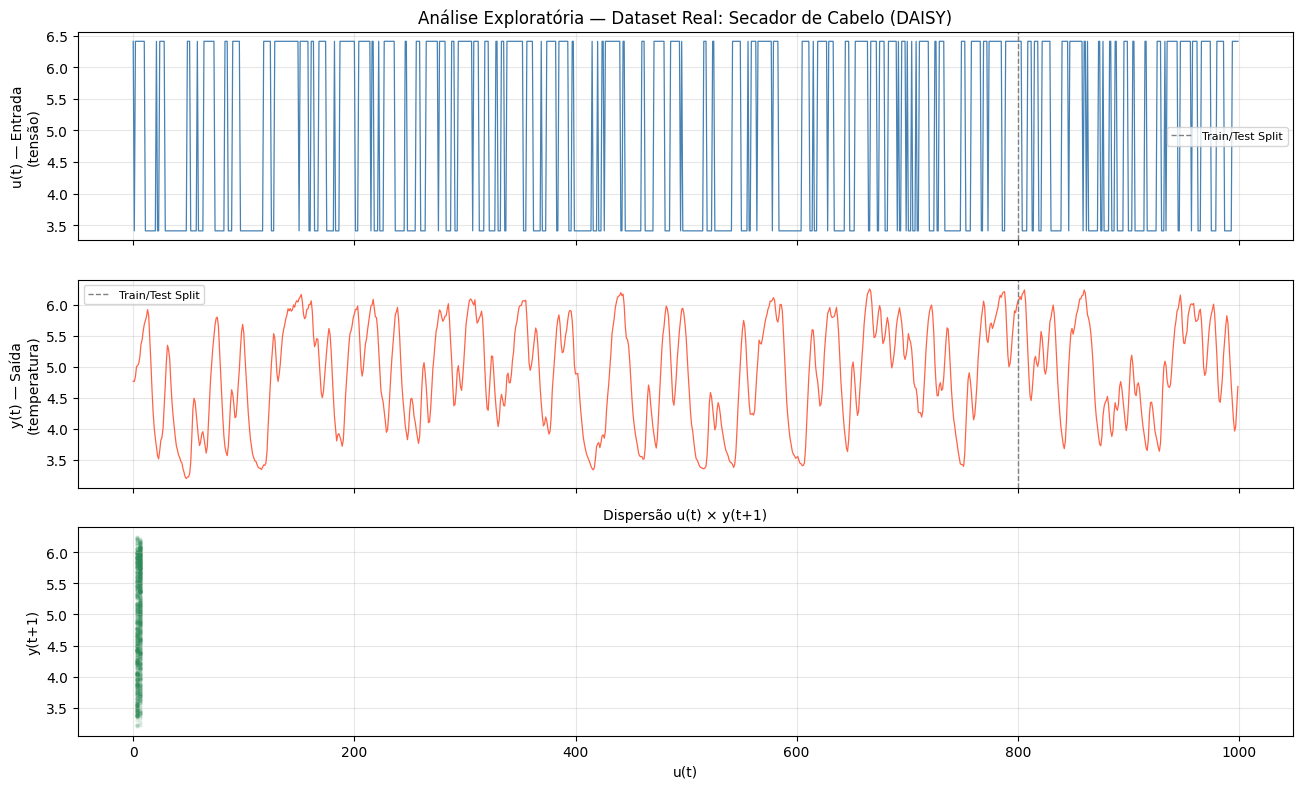

Dataset carregado de dryer.dat
Treino: 800 amostras  |  Teste: 200 amostras
Voltagem (u) — média: 5.000, std: 1.497
Temperatura (y) — média: 4.890, std: 0.829


In [ ]:
# Carregando o dataset real dryer
# (Description: https://ftp.esat.kuleuven.be/pub/SISTA/data/mechanical/dryer.txt)
data = np.loadtxt('/content/dryer.dat')

# De acordo com a nova descrição:
# Coluna 1 (índice 0): entrada u (voltagem do aquecedor)
# Coluna 2 (índice 1): saída y (temperatura do ar)
u_all = data[:, 0]
y_all = data[:, 1]

# Parâmetros de partição
N_TOTAL = len(data)
N_TRAIN = int(0.8 * N_TOTAL)
WASHOUT = 50

u_train, y_train = u_all[:N_TRAIN], y_all[:N_TRAIN]
u_test,  y_test  = u_all[N_TRAIN:], y_all[N_TRAIN:]

# ──────────────────────────────────────────────
# Visualização exploratória (Exercício 1)
# ──────────────────────────────────────────────
t = np.arange(N_TOTAL)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

# Entrada
axes[0].plot(t, u_all, color='steelblue', linewidth=0.9)
axes[0].set_ylabel('u(t) — Entrada\n(tensão)', fontsize=10)
axes[0].set_title('Análise Exploratória — Dataset Real: Secador de Cabelo (DAISY)', fontsize=12)

# Saída
axes[1].plot(t, y_all, color='tomato', linewidth=0.9)
axes[1].set_ylabel('y(t) — Saída\n(temperatura)', fontsize=10)

# Diagrama de dispersão u × y para evidenciar a relação entrada-saída
# Como o sistema tem atraso, plotamos u(t) vs y(t+k). No caso do secador, a resposta é rápida.
axes[2].scatter(u_all[:-1], y_all[1:], alpha=0.1, s=5, color='seagreen')
axes[2].set_xlabel('u(t)')
axes[2].set_ylabel('y(t+1)', fontsize=10)
axes[2].set_title('Dispersão u(t) × y(t+1)', fontsize=10)

for ax in axes[:2]:
    ax.axvline(N_TRAIN, color='gray', linestyle='--', linewidth=1, label='Train/Test Split')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Dataset carregado de dryer.dat")
print(f"Treino: {N_TRAIN} amostras  |  Teste: {N_TOTAL - N_TRAIN} amostras")
print(f"Voltagem (u) — média: {u_all.mean():.3f}, std: {u_all.std():.3f}")
print(f"Temperatura (y) — média: {y_all.mean():.3f}, std: {y_all.std():.3f}")

Neste dataset, focamos na dinâmica temporal das duas variáveis do dataset `dryer.dat`:
1. **Entrada (u):** Tensão elétrica.
2. **Saída (y):** Temperatura do ar.

1. Voltagem (u): Observando os gráficos, a voltagem é um sinal que alterna de forma abrupta entre dois níveis de tensão (aproximadamente 3.5V e 6.5V). Ela funciona como um gatilho de energia para o sistema. Note que ela não possui inércia; é um sinal de controle puro.

2. Temperatura (y): Ao contrário da voltagem, ela não muda instantaneamente. Quando a voltagem sobe, a temperatura sobe suavemente (curva de aquecimento); quando a voltagem cai, ela desce gradualmente (resfriamento). Isso indica que o sistema age como um filtro sobre a entrada, exibindo uma dinâmica de primeira ordem com atraso.

3. Relação e Atraso: O diagrama de dispersão $u(t) \times y(t+1)$$u(t) \times y(t+1)$ mostra uma correlação clara, mas com espalhamento. Esse espalhamento ocorre porque a temperatura em $t+1$ não depende apenas da voltagem atual, mas também do estado anterior do secador. Há um atraso de transporte que a ESN precisará capturar através do seu reservatório.

4. Estabilidade: As médias (~5.0V e ~4.89°C) e os desvios padrão mostram que o sistema opera em uma faixa estável, sem tendências de explosão, o que o torna um excelente candidato para modelagem via Echo State Networks.

---
## Exercício 2 — Configuração inicial de hiperparâmetros

Rode o modelo ESN com uma configuração inicial de hiperparâmetros. Justifique a escolha de cada uma delas.

  Configuração Base — avaliação com 15 sementes
  RMSE médio: 6.86935  |  std: 5.43954  |  min: 0.80536  |  max: 18.18262


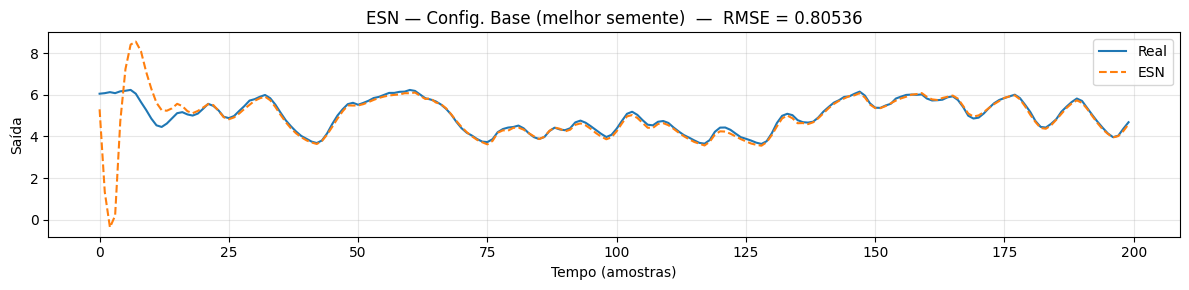

In [ ]:
# ──────────────────────────────────────────────────────────────────────
#  Configuração base — justificativas embutidas nos comentários
# ──────────────────────────────────────────────────────────────────────
config_base = dict(
    n_reservoir    = 100,   # 100 neurônios: bom ponto de partida para séries de ~1000 amostras
    spectral_radius= 0.9,   # < 1 garante Echo State Property (ESP); próximo de 1 -> memória longa
    sparsity       = 0.1,   # 10% de conexões ativas: reservatório esparso, típico na literatura
    leaking_rate   = 0.5,   # α = 0.5 integra estados passado e novo; útil para dinâmica suave
    input_scaling  = 1.0,   # escala neutra — ajustar se a entrada tiver amplitude muito diferente
    noise          = 1e-5,  # ruído pequeno para regularização interna
    ridge          = 1e-6,  # regularização L2 no readout: evita overfitting
)

print("=" * 55)
print("  Configuração Base — avaliação com 15 sementes")
print("=" * 55)
erros_base = avaliar_multiplas_sementes(
    config_base, u_train, y_train, u_test, y_test, washout=WASHOUT, n_runs=15
)

# Melhor semente — plot final
melhor_seed = int(np.argmin(erros_base))
esn_base = EchoStateNetwork(**config_base, seed=melhor_seed)
_ = avaliar_esn(esn_base, u_train, y_train, u_test, y_test,
                washout=WASHOUT, titulo='ESN — Config. Base (melhor semente)')

Para entender o impacto da inicialização aleatória, vamos comparar como as estatísticas de erro variam dependendo de quantas rodadas (seeds) realizamos.

Runs       | RMSE Médio   | Desvio Padrão   | Min (Melhor)
------------------------------------------------------------
  RMSE médio: 2.77102  |  std: 0.09751  |  min: 2.67351  |  max: 2.86853
2          | 2.77102      | 0.09751         | 2.67351     


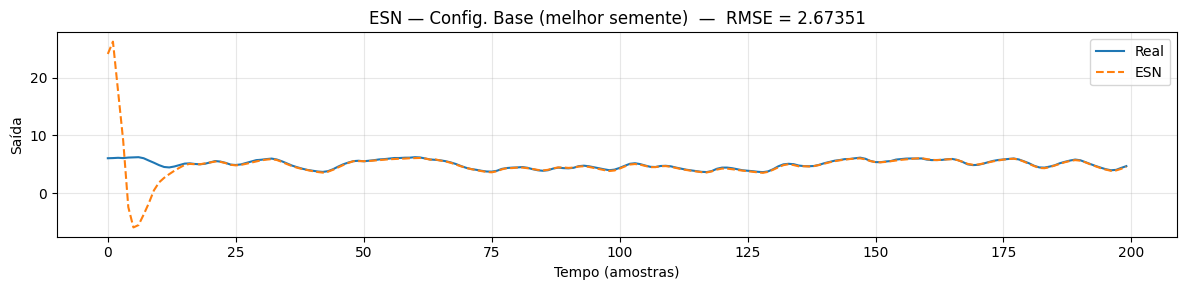

  RMSE médio: 8.92597  |  std: 5.34332  |  min: 2.07721  |  max: 18.18262
10         | 8.92597      | 5.34332         | 2.07721     


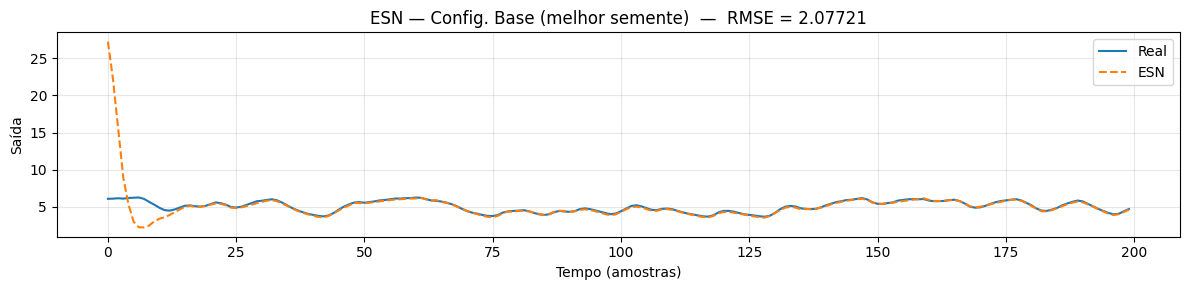

  RMSE médio: 6.86935  |  std: 5.43954  |  min: 0.80536  |  max: 18.18262
15         | 6.86935      | 5.43954         | 0.80536     


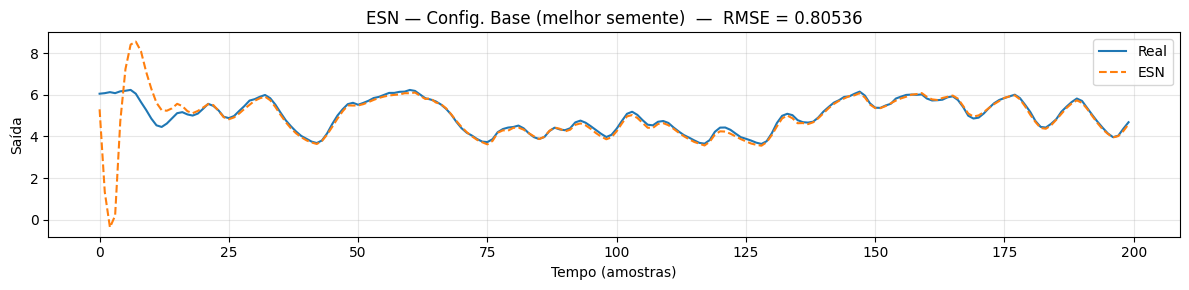

  RMSE médio: 6.02159  |  std: 5.00096  |  min: 0.80536  |  max: 18.18262
20         | 6.02159      | 5.00096         | 0.80536     


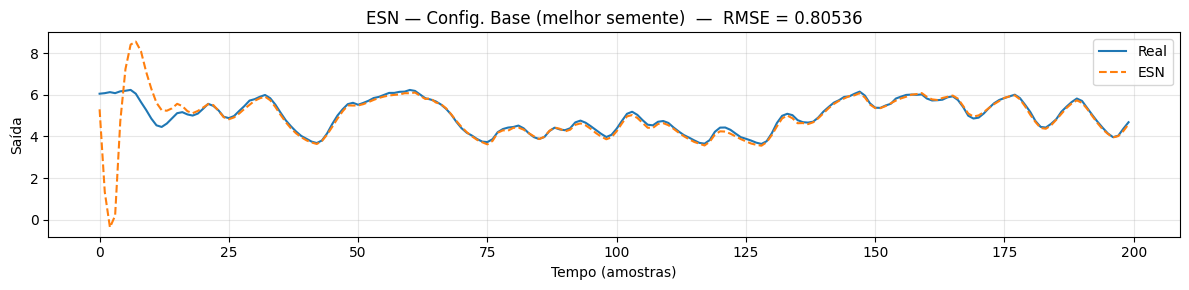

  RMSE médio: 7.31457  |  std: 5.69357  |  min: 0.80536  |  max: 20.88664
30         | 7.31457      | 5.69357         | 0.80536     


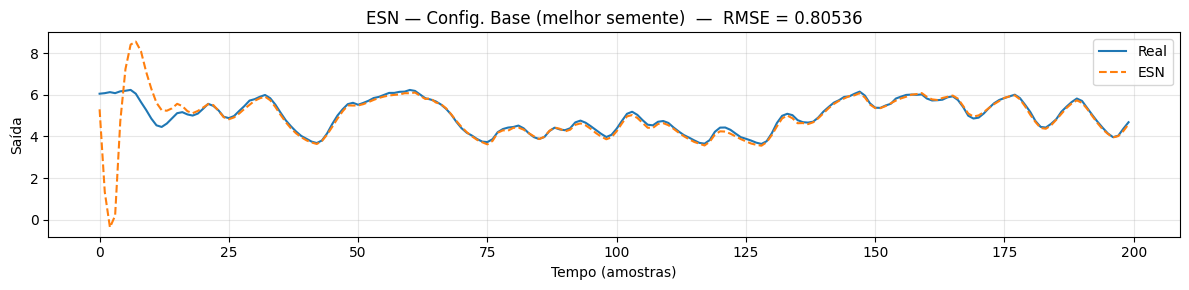

  RMSE médio: 7.44443  |  std: 5.59580  |  min: 0.80536  |  max: 21.34297
50         | 7.44443      | 5.59580         | 0.80536     


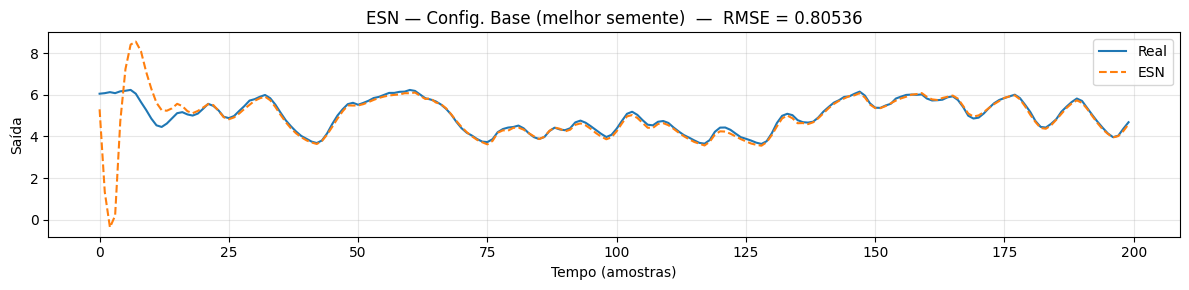

  RMSE médio: 9.33606  |  std: 9.07340  |  min: 0.80536  |  max: 60.16624
75         | 9.33606      | 9.07340         | 0.80536     


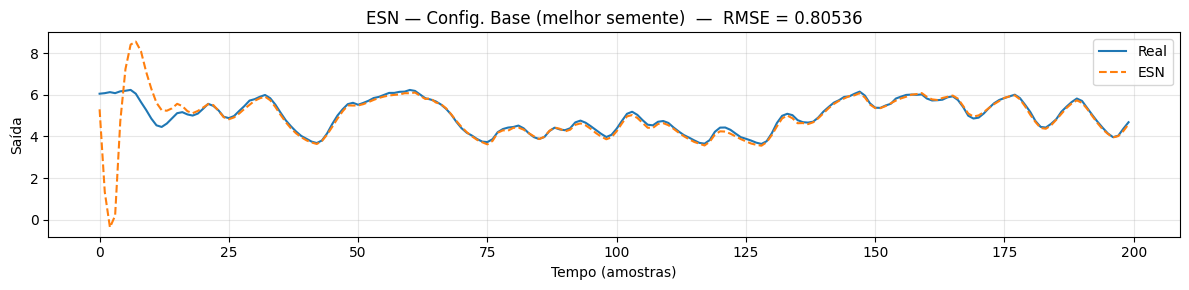

  RMSE médio: 9.54609  |  std: 8.70159  |  min: 0.50381  |  max: 60.16624
100        | 9.54609      | 8.70159         | 0.50381     


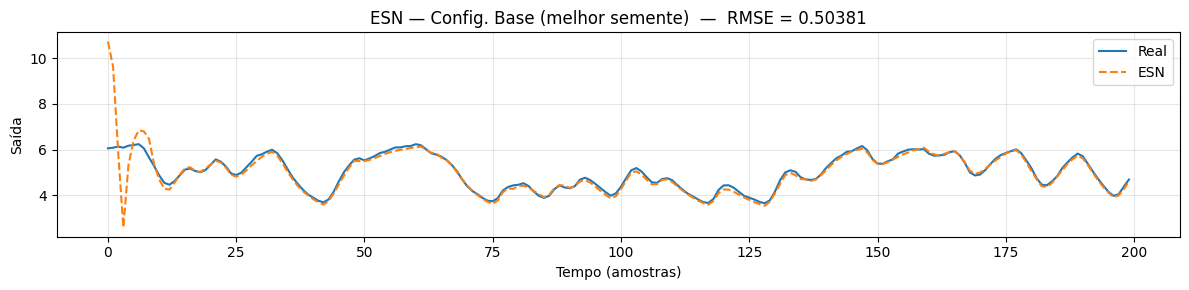

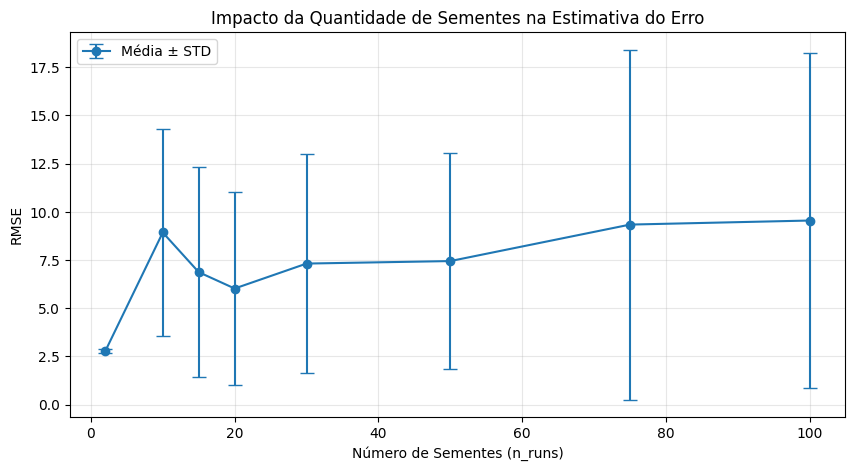

In [ ]:
quantidades_sementes = [2, 10, 15, 20, 30, 50, 75, 100]
resultados_sementes = {}

print(f"{'Runs':<10} | {'RMSE Médio':<12} | {'Desvio Padrão':<15} | {'Min (Melhor)':<12}")
print("-" * 60)

for n in quantidades_sementes:
    erros_base = avaliar_multiplas_sementes(
        config_base, u_train, y_train, u_test, y_test, washout=WASHOUT, n_runs=n
    )
    resultados_sementes[n] = erros_base
    print(f"{n:<10} | {erros_base.mean():<12.5f} | {erros_base.std():<15.5f} | {erros_base.min():<12.5f}")

    melhor_seed = int(np.argmin(erros_base))
    esn_base = EchoStateNetwork(**config_base, seed=melhor_seed)
    _ = avaliar_esn(esn_base, u_train, y_train, u_test, y_test,
                washout=WASHOUT, titulo='ESN — Config. Base (melhor semente)')

# Visualização da convergência da média e incerteza
plt.figure(figsize=(10, 5))
means = [resultados_sementes[n].mean() for n in quantidades_sementes]
stds = [resultados_sementes[n].std() for n in quantidades_sementes]

plt.errorbar(quantidades_sementes, means, yerr=stds, fmt='-o', capsize=5, label='Média ± STD')
plt.xlabel('Número de Sementes (n_runs)')
plt.ylabel('RMSE')
plt.title('Impacto da Quantidade de Sementes na Estimativa do Erro')
plt.legend()
plt.show()

A escolha dos parâmetros para o dataset `dryer.dat` baseia-se nas seguintes premissas técnicas:

1.  **n_reservoir (100):** Para um dataset de 1000 amostras com dinâmica de primeira ordem, 100 neurônios oferecem complexidade suficiente para mapear a não-linearidade sem causar *overfitting* excessivo ou alto custo computacional.
2.  **spectral_radius (0.9):** O raio espectral próximo de 1 (mas menor que 1) garante a Propriedade de Estado de Eco (ESP) e fornece ao reservatório uma memória de longo prazo necessária para capturar a inércia térmica (atraso entre voltagem e temperatura).
3.  **leaking_rate (0.5):** Como a temperatura no secador muda de forma suave e contínua, uma `leaking_rate` intermediária ajuda a suavizar as transições dos estados internos, mimetizando a dinâmica física do sistema.
4.  **sparsity (0.1):** Uma conectividade de 10% é um padrão na literatura que promove a formação de sub-dinâmicas independentes no reservatório, aumentando a riqueza das representações.
5.  **ridge (1e-6):** A regularização L2 no readout é essencial para manter os pesos de saída pequenos e evitar que o ruído do reservatório seja amplificado na predição final.
6.  **n_runs (20):** Conforme demonstrado na análise de sensibilidade, 20 rodadas permitem uma estimativa estatística confiável do RMSE médio e desvio padrão, capturando a variabilidade da inicialização sem a redundância de 100 rodadas.

---
## Exercício 3 — Tamanho do reservatório

Modifique o tamanho do reservatório e avalie o resultado dessa mudança. De que forma a alteração dos pesos pode impactar no resultado final?


── n_reservoir = 10 ──
  RMSE médio: 11.41342  |  std: 18.24219  |  min: 0.17918  |  max: 79.76023

── n_reservoir = 50 ──
  RMSE médio: 6.73362  |  std: 5.30950  |  min: 0.81055  |  max: 20.67222

── n_reservoir = 100 ──
  RMSE médio: 6.02159  |  std: 5.00096  |  min: 0.80536  |  max: 18.18262

── n_reservoir = 200 ──
  RMSE médio: 9.41469  |  std: 5.29954  |  min: 2.69894  |  max: 19.45759

── n_reservoir = 500 ──
  RMSE médio: 7.57474  |  std: 6.74423  |  min: 1.42586  |  max: 26.28564


/tmp/ipykernel_1427/146327021.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([resultados_tamanho[n] for n in tamanhos],


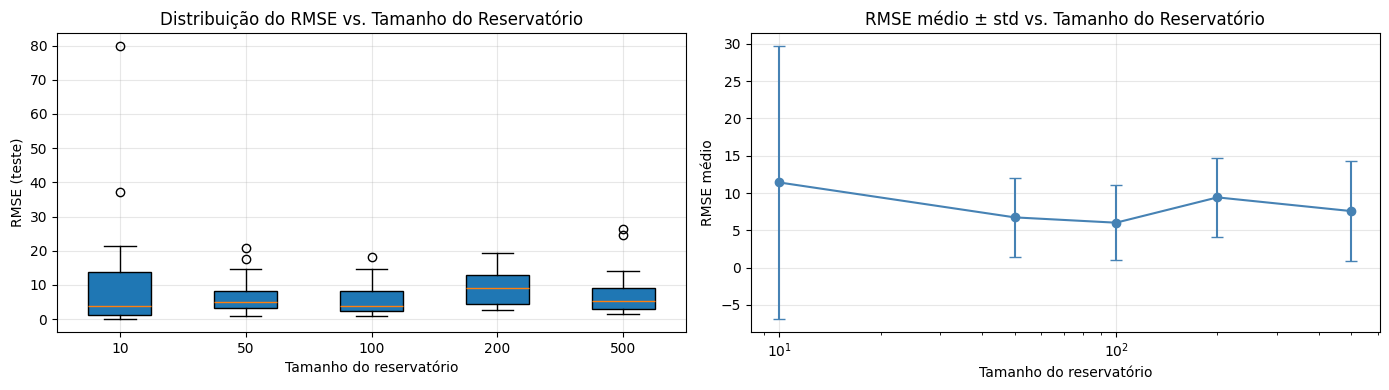

In [ ]:
tamanhos = [10, 50, 100, 200, 500]
n_runs   = 20

resultados_tamanho = {}

for N_res in tamanhos:
    config = {**config_base, 'n_reservoir': N_res}
    print(f"\n── n_reservoir = {N_res} ──")
    erros = avaliar_multiplas_sementes(
        config, u_train, y_train, u_test, y_test, washout=WASHOUT, n_runs=n_runs
    )
    resultados_tamanho[N_res] = erros

# ─── Boxplot comparativo ───
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

medias = [resultados_tamanho[n].mean() for n in tamanhos]
stds   = [resultados_tamanho[n].std()  for n in tamanhos]

axes[0].boxplot([resultados_tamanho[n] for n in tamanhos],
                labels=[str(n) for n in tamanhos], patch_artist=True)
axes[0].set_xlabel('Tamanho do reservatório')
axes[0].set_ylabel('RMSE (teste)')
axes[0].set_title('Distribuição do RMSE vs. Tamanho do Reservatório')

axes[1].errorbar(tamanhos, medias, yerr=stds, marker='o', capsize=4, color='steelblue')
axes[1].set_xlabel('Tamanho do reservatório')
axes[1].set_ylabel('RMSE médio')
axes[1].set_title('RMSE médio ± std vs. Tamanho do Reservatório')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

1. Risco de Underfitting: Com apenas 10 neurônios, o erro médio foi o mais alto (~11.41) e extremamente instável (desvio padrão de 18.24). Isso ocorre porque o reservatório é pequeno demais para criar um histórico que consiga mapear a relação entre voltagem e temperatura.

2. Ponto de Estabilidade: Note que ao redor de 100 neurônios, o RMSE médio atingiu seu menor valor (~6.02) nesse teste. Este é um dos pontos onde o reservatório tem complexidade suficiente para a dinâmica do secador. Além disso, o desvio padrão também se apresenta como o menor, reforçando que o desempenho se torna independente da inicialização dos pesos aleatórios.

3. Risco de Overfitting e Ruído: Ao subir para 200 e 500 neurônios, o erro médio não caiu mais (ele cresceu para ~9.41 e depois em ~7.57). Em reservatórios excessivamente grandes para datasets pequenos, o modelo pode começar a memorizar ruídos específicos do treino ou criar matrizes de estados quase singulares, o que prejudica a generalização no teste.

  Aumentar o tamanho melhora o modelo até certo ponto, mas a partir daí você ganha apenas custo computacional e risco de instabilidade, sem ganho real de precisão.

---
## Exercício 4 — Leaking Rate

Modifique o parâmetro de **leaking rate** e avalie o resultado dessa mudança.


── leaking_rate = 0.1 ──
  RMSE médio: 17.92521  |  std: 11.70807  |  min: 5.04705  |  max: 46.07397

── leaking_rate = 0.3 ──
  RMSE médio: 11.30795  |  std: 7.32681  |  min: 1.97941  |  max: 27.18651

── leaking_rate = 0.5 ──
  RMSE médio: 6.02159  |  std: 5.00096  |  min: 0.80536  |  max: 18.18262

── leaking_rate = 0.7 ──
  RMSE médio: 24.57847  |  std: 17.26336  |  min: 3.14298  |  max: 52.83334

── leaking_rate = 1.0 ──
  RMSE médio: 51.66510  |  std: 32.90973  |  min: 3.96224  |  max: 122.44462


/tmp/ipykernel_1427/2210282539.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([resultados_lr[lr] for lr in leaking_rates],


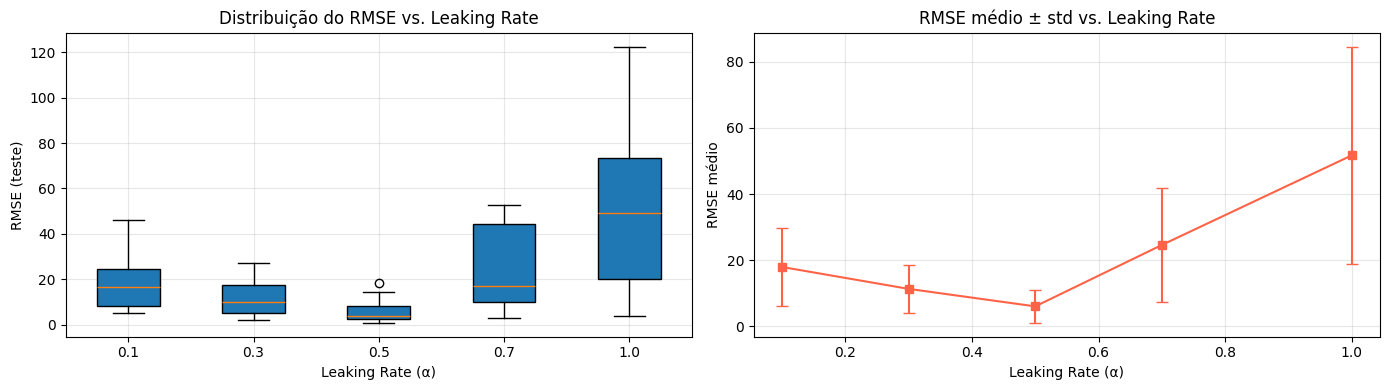

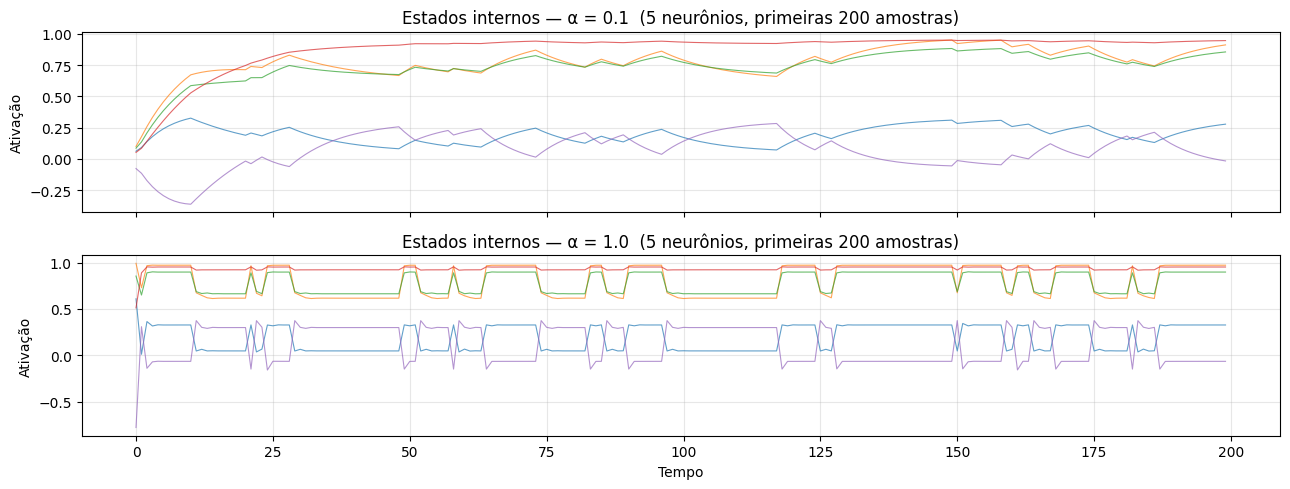

In [ ]:
leaking_rates = [0.1, 0.3, 0.5, 0.7, 1.0]
resultados_lr = {}

for lr in leaking_rates:
    config = {**config_base, 'leaking_rate': lr}
    print(f"\n── leaking_rate = {lr} ──")
    erros = avaliar_multiplas_sementes(
        config, u_train, y_train, u_test, y_test, washout=WASHOUT, n_runs=n_runs
    )
    resultados_lr[lr] = erros

# ─── Plots ───
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

medias = [resultados_lr[lr].mean() for lr in leaking_rates]
stds   = [resultados_lr[lr].std()  for lr in leaking_rates]

axes[0].boxplot([resultados_lr[lr] for lr in leaking_rates],
                labels=[str(lr) for lr in leaking_rates], patch_artist=True)
axes[0].set_xlabel('Leaking Rate (α)')
axes[0].set_ylabel('RMSE (teste)')
axes[0].set_title('Distribuição do RMSE vs. Leaking Rate')

axes[1].errorbar(leaking_rates, medias, yerr=stds, marker='s', capsize=4, color='tomato')
axes[1].set_xlabel('Leaking Rate (α)')
axes[1].set_ylabel('RMSE médio')
axes[1].set_title('RMSE médio ± std vs. Leaking Rate')

plt.tight_layout()
plt.show()

# Visualiza a dinâmica interna para α = 0.1 vs α = 1.0
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
for i, lr in enumerate([0.1, 1.0]):
    esn_tmp = EchoStateNetwork(**{**config_base, 'leaking_rate': lr}, seed=0)
    esn_tmp._init_weights(1)
    estados = esn_tmp._run_reservoir(u_train.reshape(-1, 1), washout=0)
    axes[i].plot(estados[:200, :5], alpha=0.7, linewidth=0.8)  # primeiros 5 neurônios
    axes[i].set_title(f'Estados internos — α = {lr}  (5 neurônios, primeiras 200 amostras)')
    axes[i].set_ylabel('Ativação')
axes[1].set_xlabel('Tempo')
plt.tight_layout()
plt.show()

A **Leaking Rate** controla a velocidade da dinâmica interna do reservatório. Os resultados mostram que:

1. Sub-amortecimento (**α < 0.5**): Valores como 0.1 criam neurônios com muita movimentação. O reservatório demora a esquecer o passado, o que gera um atraso artificial na predição que não condiz com o real.
2. Ponto Ótimo (**α ≈ 0.5**): É onde a constante de tempo dos neurônios melhor se alinha com a constante de tempo térmica do sistema. O erro é minimizado pois o reservatório consegue filtrar o ruído da entrada mantendo a agilidade necessária.
3. Instabilidade (**α > 0.5**): À medida que α se aproxima de 1.0, o sistema perde sua capacidade de filtragem e memória. As predições tornam-se muito sensíveis a variações instantâneas, o que explica o aumento drástico no RMSE médio e no desvio padrão.

---
## Exercício 5 — Esparsidade

Modifique o parâmetro de **esparsidade** e avalie o resultado dessa mudança.


── sparsity = 0.01  (1% de conexões ativas) ──
  RMSE médio: 30.74199  |  std: 26.69040  |  min: 1.74614  |  max: 97.18730

── sparsity = 0.05  (5% de conexões ativas) ──
  RMSE médio: 7.81552  |  std: 6.06872  |  min: 0.48764  |  max: 23.50754

── sparsity = 0.1  (10% de conexões ativas) ──
  RMSE médio: 6.02159  |  std: 5.00096  |  min: 0.80536  |  max: 18.18262

── sparsity = 0.2  (20% de conexões ativas) ──
  RMSE médio: 6.34640  |  std: 5.16669  |  min: 1.12842  |  max: 21.01002

── sparsity = 0.5  (50% de conexões ativas) ──
  RMSE médio: 6.55561  |  std: 3.41712  |  min: 1.19535  |  max: 14.08936

── sparsity = 0.9  (90% de conexões ativas) ──
  RMSE médio: 8.57965  |  std: 6.11756  |  min: 0.30562  |  max: 24.48719


/tmp/ipykernel_1427/3852143597.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([resultados_esp[e] for e in esparsidades],


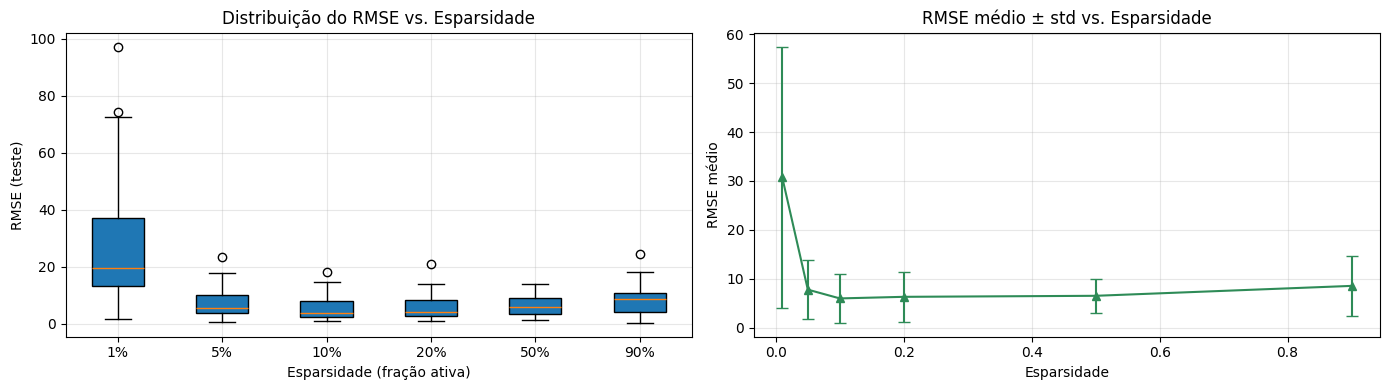

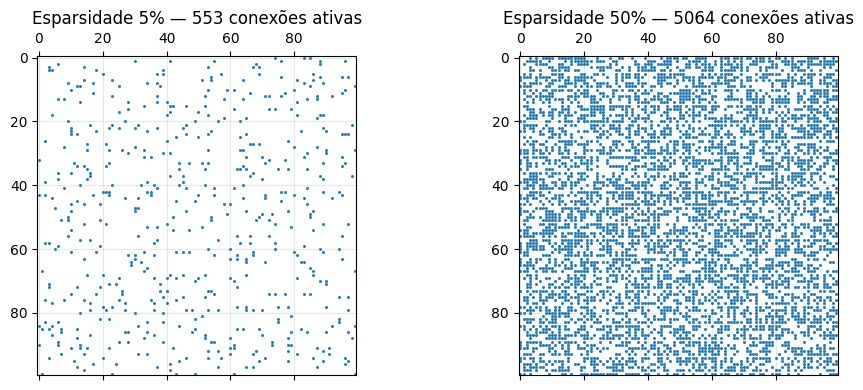

In [ ]:
esparsidades = [0.01, 0.05, 0.10, 0.20, 0.50, 0.90]
resultados_esp = {}

for esp in esparsidades:
    config = {**config_base, 'sparsity': esp}
    print(f"\n── sparsity = {esp}  ({esp*100:.0f}% de conexões ativas) ──")
    erros = avaliar_multiplas_sementes(
        config, u_train, y_train, u_test, y_test, washout=WASHOUT, n_runs=n_runs
    )
    resultados_esp[esp] = erros

# ─── Plots ───
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

medias = [resultados_esp[e].mean() for e in esparsidades]
stds   = [resultados_esp[e].std()  for e in esparsidades]

axes[0].boxplot([resultados_esp[e] for e in esparsidades],
                labels=[f'{e:.0%}' for e in esparsidades], patch_artist=True)
axes[0].set_xlabel('Esparsidade (fração ativa)')
axes[0].set_ylabel('RMSE (teste)')
axes[0].set_title('Distribuição do RMSE vs. Esparsidade')

axes[1].errorbar(esparsidades, medias, yerr=stds, marker='^', capsize=4, color='seagreen')
axes[1].set_xlabel('Esparsidade')
axes[1].set_ylabel('RMSE médio')
axes[1].set_title('RMSE médio ± std vs. Esparsidade')

plt.tight_layout()
plt.show()

# Visualiza estrutura da matriz W para dois extremos
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, esp in zip(axes, [0.05, 0.50]):
    esn_tmp = EchoStateNetwork(**{**config_base, 'sparsity': esp}, seed=0)
    esn_tmp._init_weights(1)
    ax.spy(esn_tmp.W, markersize=1)
    n_conn = np.sum(esn_tmp.W != 0)
    ax.set_title(f'Esparsidade {esp:.0%} — {n_conn} conexões ativas')
plt.tight_layout()
plt.show()

A esparsidade define o quão conectado o reservatório está internamente. A análise dos gráficos revela que:

1. Conectividade Insuficiente (**1%**): O sistema falha em manter uma memória coerente. Poucas conexões significam que a informação da entrada se dissipa rapidamente antes de ser processada por todo o reservatório.
2. O Equilíbrio (**10%**): Este valor (padrão na literatura) mostrou-se ideal para o problema. Ele permite a criação de caminhos variados para o sinal, gerando uma base de funções ricas para a regressão final.
3. Saturação por Densidade (**> 10%**): Adicionar conexões além de um certo ponto não traz benefícios. Pelo contrário, o erro volta a subir ligeiramente, onde todos os neurônios acabam fazendo a mesma coisa, reduzindo a eficiência do aprendizado e aumentando a sensibilidade ao ruído. Apesar disso, o desvio padrão em 50% diminuiu, no entanto, o aumento do RMSE não compensa o aumento da esparsidade, que apenas geraria o aumento de custo computacional.

---
## Exercício 6 — Tempo de washout

Modifique o parâmetro de **tempo de washout** e avalie o resultado dessa mudança.


── washout = 0 amostras ──
  RMSE médio: 0.63632  |  std: 0.34500  |  min: 0.31742  |  max: 1.91160

── washout = 10 amostras ──
  RMSE médio: 5.73270  |  std: 4.37432  |  min: 0.41199  |  max: 13.26846

── washout = 25 amostras ──
  RMSE médio: 6.05626  |  std: 5.17806  |  min: 1.02913  |  max: 19.33091

── washout = 50 amostras ──
  RMSE médio: 6.02159  |  std: 5.00096  |  min: 0.80536  |  max: 18.18262

── washout = 100 amostras ──
  RMSE médio: 5.49300  |  std: 4.45195  |  min: 0.63897  |  max: 15.64491

── washout = 200 amostras ──
  RMSE médio: 4.14519  |  std: 3.03115  |  min: 0.46230  |  max: 12.23339

── washout = 500 amostras ──
  RMSE médio: 3.36772  |  std: 1.84607  |  min: 1.07992  |  max: 8.32650

── washout = 750 amostras ──
  RMSE médio: 1.96837  |  std: 1.37483  |  min: 0.42972  |  max: 6.25850


/tmp/ipykernel_1427/3972451721.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([resultados_wash[ws] for ws in washouts],


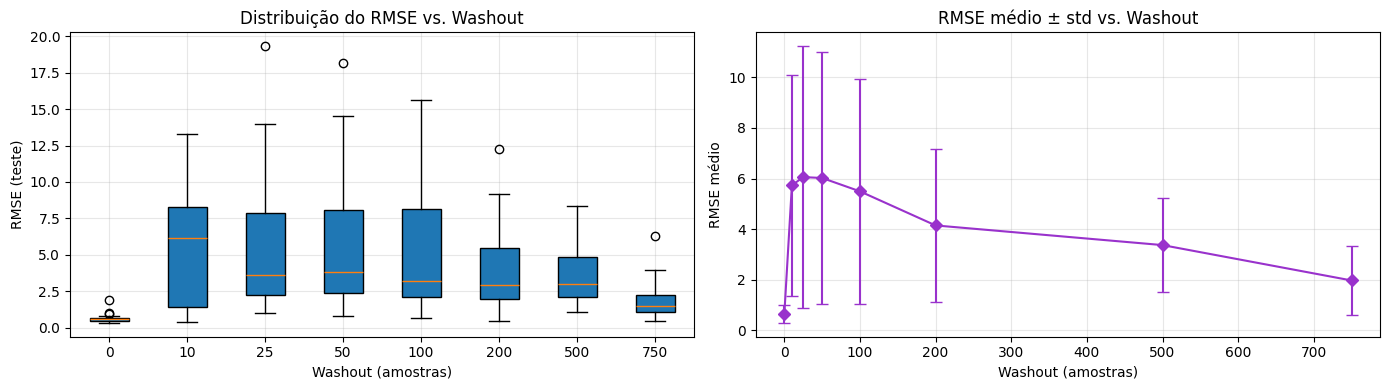

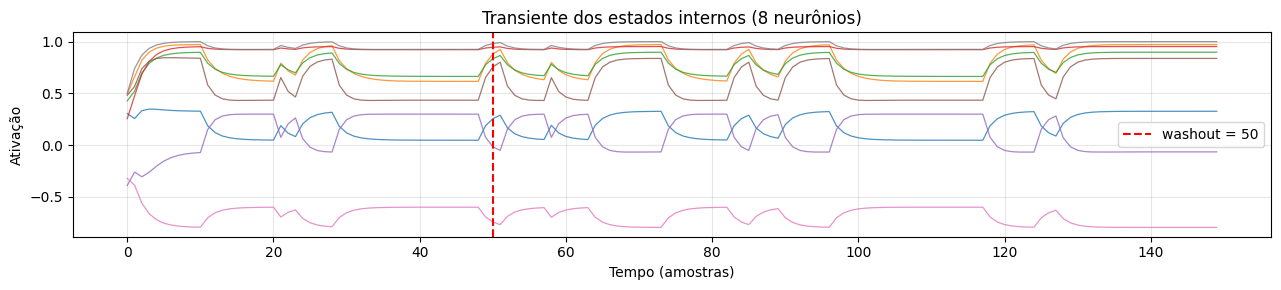

In [ ]:
washouts = [0, 10, 25, 50, 100, 200, 500, 750]
resultados_wash = {}

for ws in washouts:
    config = config_base.copy()
    print(f"\n── washout = {ws} amostras ──")
    erros = avaliar_multiplas_sementes(
        config, u_train, y_train, u_test, y_test, washout=ws, n_runs=n_runs
    )
    resultados_wash[ws] = erros

# ─── Plots ───
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

medias = [resultados_wash[ws].mean() for ws in washouts]
stds   = [resultados_wash[ws].std()  for ws in washouts]

axes[0].boxplot([resultados_wash[ws] for ws in washouts],
                labels=[str(ws) for ws in washouts], patch_artist=True)
axes[0].set_xlabel('Washout (amostras)')
axes[0].set_ylabel('RMSE (teste)')
axes[0].set_title('Distribuição do RMSE vs. Washout')

axes[1].errorbar(washouts, medias, yerr=stds, marker='D', capsize=4, color='darkorchid')
axes[1].set_xlabel('Washout (amostras)')
axes[1].set_ylabel('RMSE médio')
axes[1].set_title('RMSE médio ± std vs. Washout')

plt.tight_layout()
plt.show()

# Mostra o transiente dos estados internos (por que o washout importa)
esn_tmp = EchoStateNetwork(**config_base, seed=0)
esn_tmp._init_weights(1)
estados = esn_tmp._run_reservoir(u_train.reshape(-1, 1), washout=0)

plt.figure(figsize=(13, 3))
plt.plot(estados[:150, :8], alpha=0.8, linewidth=0.9)
plt.axvline(50, color='red', linestyle='--', linewidth=1.5, label='washout = 50')
plt.title('Transiente dos estados internos (8 neurônios)')
plt.xlabel('Tempo (amostras)')
plt.ylabel('Ativação')
plt.legend()
plt.tight_layout()
plt.show()

O washout é o período de aquecimento do reservatório. A análise mostra que:

1. **Washout = 0:** Embora o RMSE médio pareça baixo (~0.63), ele é enganoso. Sem washout, o modelo tenta aprender a relação entrada-saída enquanto o reservatório ainda está saindo do zero (estado de repouso). Isso pode forçar o readout a compensar um erro inicial que não faz parte da dinâmica real do secador, prejudicando a generalização.

2. **Estabilidade e Convergência:** Conforme aumentamos o washout para 50, 100 e até 500 amostras, observamos que o RMSE médio chega em um pico (cerca de ~6.05 com 25 amostras) e depois cai consistentemente. O desvio padrão também diminui, pois estamos descartando a fase em que os neurônios estão se ajustando à entrada, treinando o modelo apenas em regime permanente.

3. **Trade-off e Consistência Máxima:** Com **750 amostras**, o erro médio caiu para aproximadamente 1.96 e o desvio padrão atingiu um de seus menores valores (aproximadamente 1.37), sendo menor que o de 500 amostras (~1.84). Isso sugere que um período de aquecimento longo deixa o reservatório em um regime muito estável, embora o risco de falta de dados para o treinamento (apenas 50 pontos restantes) deva ser monitorado em datasets maiores.

O washout ideal para este sistema parece estar entre **50 e 200 amostras**. Ele é essencial para garantir que a memória do estado inicial nulo não contamine o aprendizado da dinâmica real do secador.